In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
class ExpenseTracker:

    def __init__(self, filename):
        self.filename = filename
        self.df = None

In [3]:
class ExpenseTracker(ExpenseTracker):

    def load_data(self):
        self.df = pd.read_csv(self.filename)
        print("Dataset Loaded Successfully")
        display(self.df.head())

In [4]:
class ExpenseTracker(ExpenseTracker):

    def dataset_info(self):

        print("Shape of Dataset")
        print(self.df.shape)

        print("\nInformation")
        self.df.info()

        print("\nFirst Five Rows")
        display(self.df.head())

        print("\nLast Five Rows")
        display(self.df.tail())

In [5]:
class ExpenseTracker(ExpenseTracker):

    def handle_missing_values(self):

        print("Missing Values Before Cleaning")
        print(self.df.isnull().sum())

        self.df["Amount"] = self.df["Amount"].fillna(self.df["Amount"].mean())

        self.df["Quantity"] = self.df["Quantity"].fillna(self.df["Quantity"].median())

        self.df["MonthlyBudget"] = self.df["MonthlyBudget"].fillna(self.df["MonthlyBudget"].median())

        self.df["Merchant"] = self.df["Merchant"].fillna("Unknown")

        self.df["Description"] = self.df["Description"].fillna("No Description")

        print("\nMissing Values After Cleaning")
        print(self.df.isnull().sum())

In [6]:
class ExpenseTracker(ExpenseTracker):

    def remove_duplicates(self):

        print("Before :", self.df.shape)

        self.df.drop_duplicates(inplace=True)

        print("After :", self.df.shape)

In [7]:
class ExpenseTracker(ExpenseTracker):

    def summary(self):

        display(self.df.describe())

        print("\nCategories")
        print(self.df["Category"].unique())

        print("\nPayment Methods")
        print(self.df["PaymentMethod"].unique())

In [8]:
class ExpenseTracker(ExpenseTracker):

    def numpy_analysis(self):

        amount = np.array(self.df["Amount"])

        print("Total Expense :", np.sum(amount))

        print("Average Expense :", np.mean(amount))

        print("Maximum Expense :", np.max(amount))

        print("Minimum Expense :", np.min(amount))

        print("Median Expense :", np.median(amount))

        print("Standard Deviation :", np.std(amount))

In [9]:
class ExpenseTracker(ExpenseTracker):

    def group_analysis(self):

        category_total = self.df.groupby("Category")["Amount"].sum()

        print("Expense By Category")

        display(category_total)

        payment = self.df.groupby("PaymentMethod")["Amount"].sum()

        print("Expense By Payment Method")

        display(payment)

        top = category_total.sort_values(ascending=False)

        print("Top Categories")

        display(top)

In [10]:
class ExpenseTracker(ExpenseTracker):

    def bar_graph(self):

        category = self.df.groupby("Category")["Amount"].sum()

        plt.figure(figsize=(10,5))

        plt.bar(category.index, category.values, color="skyblue")

        plt.xticks(rotation=45)

        plt.title("Expense By Category")

        plt.xlabel("Category")

        plt.ylabel("Amount")

        save = input("Do you want to save graph (yes/no): ")

        if save.lower() == "yes":

            plt.savefig("barchart.png",
                        dpi=300,
                        bbox_inches="tight")

            print("Graph Saved Successfully!")

        plt.show()

In [11]:
class ExpenseTracker(ExpenseTracker):

    def line_graph(self):

        self.df["Date"] = pd.to_datetime(self.df["Date"])

        self.df["Month"] = self.df["Date"].dt.month

        monthly = self.df.groupby("Month")["Amount"].sum()

        plt.figure(figsize=(10,5))

        plt.plot(monthly.index,
                 monthly.values,
                 marker="o",
                 color="red")

        plt.title("Monthly Expense Trend")

        plt.xlabel("Month")

        plt.ylabel("Expense")

        plt.grid(True)

        save = input("Do you want to save graph (yes/no): ")

        if save.lower() == "yes":

            plt.savefig("Linegraph.png",
                        dpi=300,
                        bbox_inches="tight")

            print("Graph Saved Successfully!")

        plt.show()

In [12]:
class ExpenseTracker(ExpenseTracker):

    def pie_chart(self):

        category = self.df.groupby("Category")["Amount"].sum()

        plt.figure(figsize=(8,8))

        plt.pie(category.values,
                labels=category.index,
                autopct="%1.1f%%",
                startangle=90)

        plt.title("Expense Distribution")

        save = input("Do you want to save graph (yes/no): ")

        if save.lower() == "yes":

            plt.savefig("Piechart.png",
                        dpi=300,
                        bbox_inches="tight")

            print("Graph Saved Successfully!")

        plt.show()

In [13]:
class ExpenseTracker(ExpenseTracker):

    def histogram(self):

        plt.figure(figsize=(12,5))

        sns.histplot(data=self.df,
                     x="Merchant",
                     color="purple")

        plt.xticks(rotation=45)

        plt.xlabel("Merchant")

        plt.ylabel("Count")

        plt.title("Merchant Distribution")

        save = input("Do you want to save graph (yes/no): ")

        if save.lower() == "yes":

            plt.savefig("Histogram.png",
                        dpi=300,
                        bbox_inches="tight")

            print("Graph Saved Successfully!")

        plt.show()

In [14]:
tracker = ExpenseTracker("dataset.csv")

In [15]:
tracker.load_data()

Dataset Loaded Successfully


,ExpenseID,Date,Category,Amount,Quantity,MonthlyBudget,PaymentMethod,Description,Merchant,City
0,1,2025-05-21,Health,NaN,15.0,49566.0,Debit Card,Expense 1,Flipkart,Rajkot
1,2,2025-11-07,Fuel,4775.0,13.0,55471.0,Wallet,Expense 2,Amazon,Vadodara
2,3,2025-10-13,Transport,1731.0,14.0,37066.0,Debit Card,Expense 3,DMart,Ahmedabad
3,4,2025-04-14,Food,16883.0,1.0,16707.0,UPI,Expense 4,Uber,Surat
4,5,2025-12-26,Bills,8567.0,7.0,10349.0,Cash,Expense 5,Amazon,Bangalore


In [16]:
tracker.dataset_info()

Shape of Dataset
(5000, 10)

Information
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ExpenseID      5000 non-null   int64  
 1   Date           5000 non-null   str    
 2   Category       5000 non-null   str    
 3   Amount         4776 non-null   float64
 4   Quantity       4766 non-null   float64
 5   MonthlyBudget  4737 non-null   float64
 6   PaymentMethod  5000 non-null   str    
 7   Description    4736 non-null   str    
 8   Merchant       4703 non-null   str    
 9   City           5000 non-null   str    
dtypes: float64(3), int64(1), str(6)
memory usage: 390.8 KB

First Five Rows


,ExpenseID,Date,Category,Amount,Quantity,MonthlyBudget,PaymentMethod,Description,Merchant,City
0,1,2025-05-21,Health,NaN,15.0,49566.0,Debit Card,Expense 1,Flipkart,Rajkot
1,2,2025-11-07,Fuel,4775.0,13.0,55471.0,Wallet,Expense 2,Amazon,Vadodara
2,3,2025-10-13,Transport,1731.0,14.0,37066.0,Debit Card,Expense 3,DMart,Ahmedabad
3,4,2025-04-14,Food,16883.0,1.0,16707.0,UPI,Expense 4,Uber,Surat
4,5,2025-12-26,Bills,8567.0,7.0,10349.0,Cash,Expense 5,Amazon,Bangalore



Last Five Rows


,ExpenseID,Date,Category,Amount,Quantity,MonthlyBudget,PaymentMethod,Description,Merchant,City
4995,4996,2025-11-04,Travel,10752.0,4.0,7061.0,Debit Card,Expense 4996,Reliance Fresh,Bangalore
4996,4997,2025-10-04,Shopping,19394.0,9.0,12533.0,Debit Card,Expense 4997,Ola,Delhi
4997,4998,2025-08-19,Bills,9745.0,9.0,30539.0,Net Banking,Expense 4998,Zomato,Surat
4998,4999,2025-09-03,Entertainment,8851.0,10.0,55285.0,Debit Card,Expense 4999,Uber,Surat
4999,5000,2025-06-07,Groceries,4855.0,NaN,40859.0,Net Banking,Expense 5000,Flipkart,Rajkot


In [17]:
tracker.handle_missing_values()

Missing Values Before Cleaning
ExpenseID          0
Date               0
Category           0
Amount           224
Quantity         234
MonthlyBudget    263
PaymentMethod      0
Description      264
Merchant         297
City               0
dtype: int64

Missing Values After Cleaning
ExpenseID        0
Date             0
Category         0
Amount           0
Quantity         0
MonthlyBudget    0
PaymentMethod    0
Description      0
Merchant         0
City             0
dtype: int64


In [18]:
tracker.remove_duplicates()

Before : (5000, 10)
After : (5000, 10)


In [19]:
tracker.summary()

,ExpenseID,Amount,Quantity,MonthlyBudget
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,10179.461683,8.010400,32228.840800
std,1443.520003,5648.047014,4.258018,15435.861775
min,1.000000,53.000000,1.000000,5001.000000
25%,1250.750000,5509.500000,4.000000,19298.500000
50%,2500.500000,10179.461683,8.000000,32146.000000
75%,3750.250000,14920.250000,12.000000,45245.250000
max,5000.000000,19996.000000,15.000000,59998.000000



Categories
<StringArray>
[       'Health',          'Fuel',     'Transport',          'Food',
         'Bills',        'Travel',          'Rent',      'Shopping',
     'Groceries',     'Education', 'Entertainment',       'Medical']
Length: 12, dtype: str

Payment Methods
<StringArray>
['Debit Card', 'Wallet', 'UPI', 'Cash', 'Net Banking', 'Credit Card']
Length: 6, dtype: str


In [20]:
tracker.numpy_analysis()

Total Expense : 50897308.417085424
Average Expense : 10179.461683417085
Maximum Expense : 19996.0
Minimum Expense : 53.0
Median Expense : 10179.461683417085
Standard Deviation : 5647.482181237725


In [21]:
tracker.group_analysis()

Expense By Category


Category
Bills            4.383821e+06
Education        4.104254e+06
Entertainment    4.337798e+06
Food             3.887444e+06
Fuel             4.178039e+06
Groceries        4.218899e+06
Health           4.388488e+06
Medical          4.252970e+06
Rent             4.200459e+06
Shopping         4.624974e+06
Transport        4.122437e+06
Travel           4.197726e+06
Name: Amount, dtype: float64

Expense By Payment Method


PaymentMethod
Cash           8.337245e+06
Credit Card    8.563104e+06
Debit Card     8.653284e+06
Net Banking    7.771138e+06
UPI            8.557435e+06
Wallet         9.015101e+06
Name: Amount, dtype: float64

Top Categories


Category
Shopping         4.624974e+06
Health           4.388488e+06
Bills            4.383821e+06
Entertainment    4.337798e+06
Medical          4.252970e+06
Groceries        4.218899e+06
Rent             4.200459e+06
Travel           4.197726e+06
Fuel             4.178039e+06
Transport        4.122437e+06
Education        4.104254e+06
Food             3.887444e+06
Name: Amount, dtype: float64

Do you want to save graph (yes/no):  yes


Graph Saved Successfully!


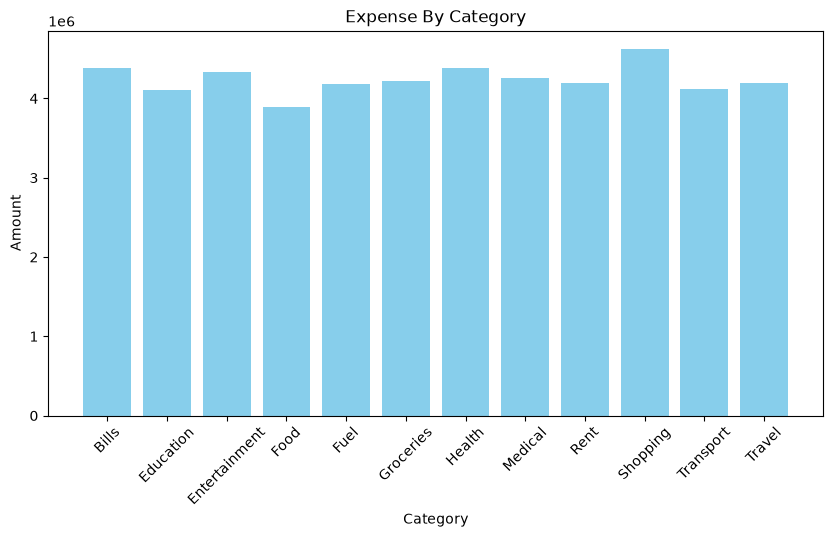

In [22]:
tracker.bar_graph()

Do you want to save graph (yes/no):  yes


Graph Saved Successfully!


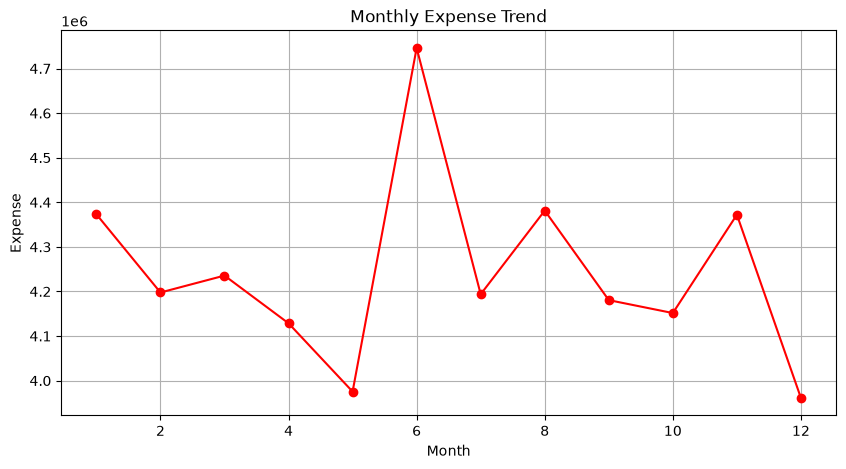

In [23]:
tracker.line_graph()

Do you want to save graph (yes/no):  yes


Graph Saved Successfully!


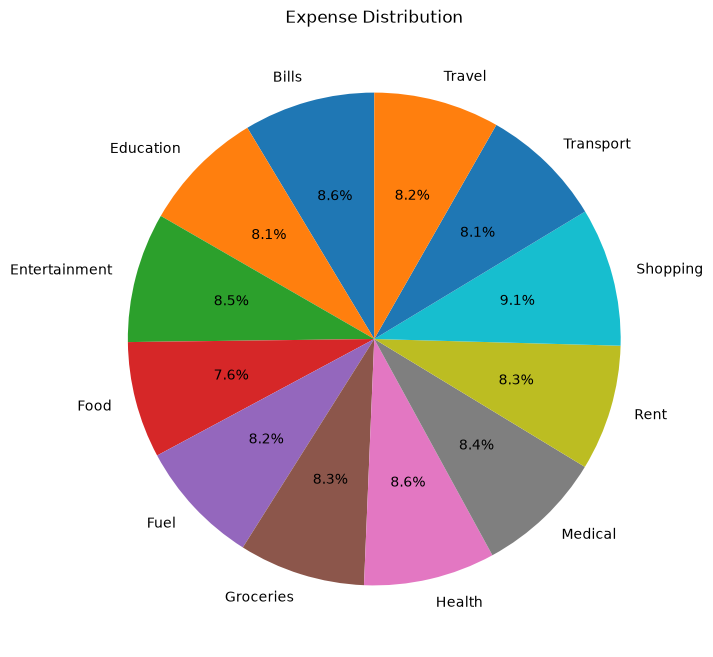

In [24]:
tracker.pie_chart()

Do you want to save graph (yes/no):  yes


Graph Saved Successfully!


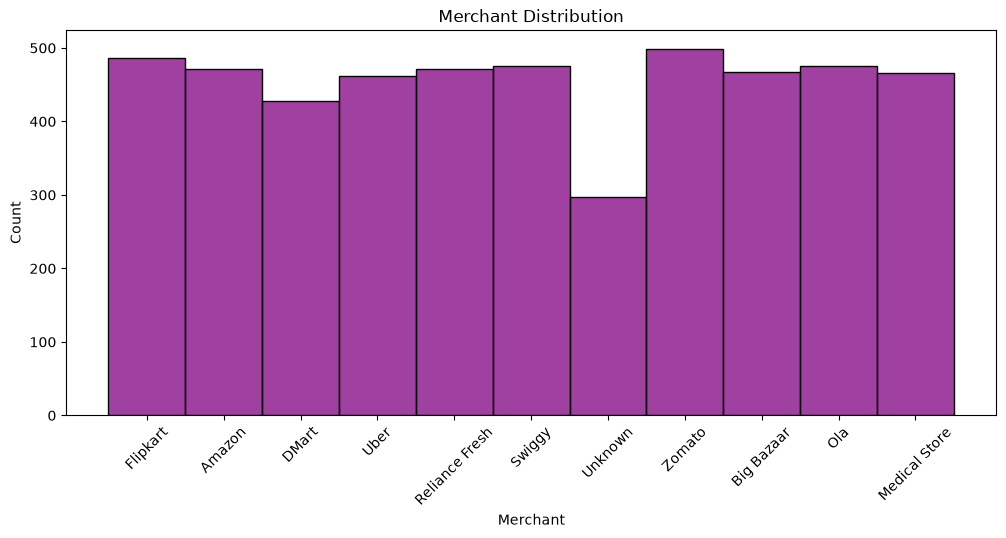

In [25]:
tracker.histogram()

The Smart Expense Tracker analysis successfully cleaned and processed the expense dataset by handling missing values and removing duplicate records, resulting in reliable and consistent data for analysis. Statistical analysis using NumPy provided key insights such as total, average, maximum, minimum, median, and standard deviation of expenses, helping to understand overall spending behavior. Group-wise analysis identified the categories and payment methods with the highest expenses, while visualizations (bar chart, line graph, pie chart, and histogram) clearly illustrated spending distribution, monthly expense trends, category-wise expenditure, and merchant frequency. Overall, the project demonstrates that data analysis and visualization can effectively monitor personal expenses, identify spending patterns, support budget planning, and enable better financial decision-making.